<a href="https://colab.research.google.com/github/jjmoncus/MV_coursework_2/blob/main/Machine_Vision_Final_Lab_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Need to somehow figure out how to get the right python version on colab

In [1]:
import sys
print(sys.version)

3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:07:49) [Clang 20.1.8 ]


# Load Dependencies

In [2]:
!pip install boto3 -q
!pip install opencv-python torch numpy torchvision
!pip install seaborn
!pip install huggingface_hub
!pip install mediapipe==0.10.13

ERROR: Could not find a version that satisfies the requirement mediapipe==0.10.13 (from versions: 0.10.30, 0.10.31)
ERROR: No matching distribution found for mediapipe==0.10.13


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau

import os
import cv2
import numpy as np
import shutil
import random
import psutil

from tqdm import tqdm
import time
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import mediapipe as mp

import warnings

# Suppress Protobuf and MediaPipe internal warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 
warnings.filterwarnings("ignore", category=UserWarning, module='google.protobuf.symbol_database')

# Find and apply device

In [4]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


# Download the data

In [5]:
import boto3
from botocore import UNSIGNED
from botocore.config import Config
import os

# Connect to S3 without authentication (public bucket)
s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))

bucket_name = 'prism-mvta'
prefix = 'training-and-validation-data/'
download_dir = './video-data'

# refresh `download_dir` if already exists
if os.path.exists(download_dir):
    shutil.rmtree(download_dir)
    print(f"Removed {download_dir}")
else:
    print(f"{download_dir} not found - making now.")
os.makedirs(download_dir, exist_ok=True)

# List all objects in the S3 path
paginator = s3.get_paginator('list_objects_v2')
pages = paginator.paginate(Bucket=bucket_name, Prefix=prefix)

video_names = []

for page in pages:
    if 'Contents' not in page:
        print("No files found at the specified path! Go and complain to the TAs!")
        break

    for obj in page['Contents']:
        key = obj['Key']
        filename = os.path.basename(key)

        if not filename:
            continue

        video_names.append(filename)

        local_path = os.path.join(download_dir, filename)
        print(f"Downloading: {filename}")
        s3.download_file(bucket_name, key, local_path)

print("\n" + "="*50)
print("Downloaded videos:")
print("="*50)
for name in video_names:
    print(name)

print(f"\nTotal: {len(video_names)} files")

Removed ./video-data
Downloading: 1_dksksjfwijf.mp4
Downloading: 2_dfsaeklnvvalkej.mp4
Downloading: 2_difficult_2.mp4
Downloading: 2_difficult_sdafkljsalkfj.mp4
Downloading: 2_dkdjwkndkfw.mp4
Downloading: 2_dkdmkejkeimdh.mp4
Downloading: 2_dkjd823kjf.mp4
Downloading: 2_dsalkfjalwkenlke.mp4
Downloading: 2_kling_20251205_Text_to_Video_On_a_sandy_4976_0.mp4
Downloading: 2_kling_20251206_Text_to_Video_Generate_a_71_1.mp4
Downloading: 2_sadfasjldkfjaseifj.mp4
Downloading: 2_sdafkjaslkclaksdjkas.mp4
Downloading: 2_sdfkjsaleijflaskdjf.mp4
Downloading: 2_sdjfhafsldkjhjk.mp4
Downloading: 2_sdkjdsflkjfwa.mp4
Downloading: 2_sdlfjlewlkjkj.mp4
Downloading: 2_sdlkjsaelijfksdjf.mp4
Downloading: 3_asldkfjalwieaskdfaskdf.mp4
Downloading: 3_dkk873lkjlksajdf.mp4
Downloading: 3_dsjlaeijlksjdfie.mp4
Downloading: 3_dsksdfjbvsdkj.mp4
Downloading: 3_dslkaldskjflakjs.mp4
Downloading: 3_ewdfkjwaeoihjlkasdjf.mp4
Downloading: 3_kling_20251205_Text_to_Video_In_a_grass_4697_0.mp4
Downloading: 3_kling_20251205_Text_

# Preprocess videos through mediapipe to get pose information for subject

Initialize mediapipe model

In [6]:
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=False, min_detection_confidence=0.5)

I0000 00:00:1767399928.614232 5322102 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 88), renderer: Apple M1 Pro


Function for extracting mediapope joint coordinates

In [7]:
def extract_mediapipe_tensor(video_tensor):
    """
    Input: video_tensor of shape (C, T, H, W)
    Output: result_tensor of shape (T, 33, 4)
    """
    C, T, H, W = video_tensor.shape
    
    # Pre-allocate output tensor (T frames, 33 landmarks, 4 features: x, y, z, vis)
    output_data = torch.zeros((T, 33, 4))

    for t in range(T):
        # 1. Slice the frame: (C, H, W)
        frame = video_tensor[:, t, :, :]
        
        # 2. Permute to (H, W, C) and convert to Numpy
        # Note: If your tensor is BGR, use frame[[2, 1, 0], :, :].permute...
        frame_np = frame.permute(1, 2, 0).cpu().numpy()
        
        # 3. Ensure uint8 format (MediaPipe requires 0-255)
        if frame_np.dtype != np.uint8:
            if frame_np.max() <= 1.01:
                frame_np = (frame_np * 255).astype(np.uint8)
            else:
                frame_np = frame_np.astype(np.uint8)

        # 4. Process frame
        results = pose.process(frame_np)

        # 5. Fill landmark data if a person is detected
        if results.pose_landmarks:
            for i, lm in enumerate(results.pose_landmarks.landmark):
                output_data[t, i, 0] = lm.x
                output_data[t, i, 1] = lm.y
                output_data[t, i, 2] = lm.z
                output_data[t, i, 3] = lm.visibility
        else:
            # If no detection, the frame remains zeros
            pass
            
    return output_data

Function for batch extracting poses from a bunch of videos

In [ ]:
def export_poses(video_paths, search_dir, output_dir):
    """
    Iterates through video_paths, extracts pose data, and saves as .pt tensors.
    """
    print("\nEstimating Poses in Training Videos...\n")
    
    # 1. Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)
    
    # Initialize MediaPipe once
    mp_pose = mp.solutions.pose
    pose_processor = mp_pose.Pose(static_image_mode=False, min_detection_confidence=0.5)

    # Wrap the loop with tqdm for a progress bar
    for video_name in tqdm(video_paths, desc="Processing Videos", unit="video"):
        # 2. Construct full input path
        video_input_path = os.path.join(search_dir, video_name)
        
        if not os.path.exists(video_input_path):
            # Using tqdm.write prevents the progress bar from breaking
            tqdm.write(f"⚠️ Skip: {video_name} not found in {search_dir}")
            continue

        # 3. Extract landmarks using OpenCV loop
        cap = cv2.VideoCapture(video_input_path)
        all_landmarks = []
        
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = pose_processor.process(frame_rgb)
            
            current_frame = np.zeros((33, 4))
            if results.pose_landmarks:
                for i, lm in enumerate(results.pose_landmarks.landmark):
                    current_frame[i] = [lm.x, lm.y, lm.z, lm.visibility]
            
            all_landmarks.append(current_frame)
        
        cap.release()

        # 4. Convert to Torch Tensor [T, 33, 4]
        video_tensor = torch.from_numpy(np.array(all_landmarks)).float()

        # 5. Save to Output Directory
        base_name = os.path.splitext(video_name)[0]
        output_filename = f"{base_name}_pose.pt"
        save_path = os.path.join(output_dir, output_filename)
        
        torch.save(video_tensor, save_path)
        
        # Uncommenting the official "saved" write statement for now
        # tqdm.write(f"✅ Saved: {output_filename}")

Perform batch extraction

In [9]:
video_paths = [f for f in os.listdir("./video-data") if f.endswith(('.mp4', '.avi', '.mov'))]
export_poses(video_paths, "video-data", "pose-data")

I0000 00:00:1767399928.662431 5322102 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 88), renderer: Apple M1 Pro



Estimating Poses in Test Videos...



Processing Videos: 100%|██████████| 77/77 [06:01<00:00,  4.69s/video]


# Transform pose data to help with class imbalances

Some functions for lengthening or shortening videos by concatenating (or cutting) frames

In [10]:
def double_length(paths, search_dir = "pose-data", out_dir = "train-data"):
    
    # Ensure output directory exists
    os.makedirs(out_dir, exist_ok=True)

    for video_path in paths:
    
        full_path = f"{search_dir}/{video_path}"

        original_label = int(video_path.split('_')[0])
        pattern = f"{original_label}_"
        rest = video_path.replace(pattern, "", 1)
        base_name = os.path.splitext(rest)[0]
        new_label = original_label * 2
        
        output_path = f"{out_dir}/{new_label}_DOUBLED_{base_name}.pt"

        frames = torch.load(full_path)
        reversed_frames = torch.flip(frames, dims=[0])
        out = torch.cat([frames, reversed_frames])
        
        torch.save(out, output_path)
        print(f"✅ Saved: {output_path}")
        


def triple_length(paths, search_dir = "pose-data", out_dir = "train-data"):
    
    # Ensure output directory exists
    os.makedirs(out_dir, exist_ok=True)

    for video_path in paths:
    
        full_path = f"{search_dir}/{video_path}"

        original_label = int(video_path.split('_')[0])
        pattern = f"{original_label}_"
        rest = video_path.replace(pattern, "", 1)
        base_name = os.path.splitext(rest)[0]
        new_label = original_label * 3
        
        output_path = f"{out_dir}/{new_label}_TRIPLED_{base_name}.pt"
        
        frames = torch.load(full_path)
        reversed_frames = torch.flip(frames, dims=[0])
        out = torch.cat([frames, reversed_frames, frames])
        
        torch.save(out, output_path)
        print(f"✅ Saved: {output_path}")

def cut_in_half(paths, search_dir = "pose-data", out_dir = "train-data"):

    for video_path in paths:
        
        full_path = f"{search_dir}/{video_path}"

        original_label = int(video_path.split('_')[0])
        pattern = f"{original_label}_"
        rest = video_path.replace(pattern, "", 1)
        base_name = os.path.splitext(rest)[0]
        new_label = int(original_label / 2)
        
        frames = torch.load(full_path)
        # Calculate the midpoint
        midpoint = len(frames) // 2
        first = frames[:midpoint, :, :]
        second = frames[midpoint:, :, :]

        output_path_1 = f"{out_dir}/{new_label}_SPLIT_FIRST_{base_name}.pt"
        output_path_2 = f"{out_dir}/{new_label}_SPLIT_SECOND_{base_name}.pt"

        # Save both halves
        torch.save(first, output_path_1)
        torch.save(second, output_path_2)

        print(f"Video split successfully at frame {midpoint}")


def three_to_five(paths, search_dir = "pose-data", out_dir = "train-data"):

    for video_path in paths:
    
        full_path = f"{search_dir}/{video_path}"

        original_label = 3
        pattern = f"{original_label}_"
        rest = video_path.replace(pattern, "", 1)
        new_label = 5
        
        output_path = f"{out_dir}/{new_label}_STITCHED_{rest}"

        frames = torch.load(full_path)
        cutoff_index = int(len(frames) * 0.66)

        reversed_frames = torch.flip(frames, dims=[0])
        clipped_palindrome = reversed_frames[:cutoff_index]
        out = torch.cat([frames, clipped_palindrome])

        torch.save(out, output_path)
        print(f"✅ Saved: {output_path}: Total new frames = {len(frames) + len(clipped_palindrome)}")



def four_to_seven(paths, search_dir = "pose-data", out_dir = "train-data"):

    for video_path in paths:
    
        full_path = f"{search_dir}/{video_path}"

        original_label = 4
        pattern = f"{original_label}_"
        rest = video_path.replace(pattern, "", 1)
        new_label = 7
        
        output_path = f"{out_dir}/{new_label}_STITCHED_{rest}"
        
        frames = torch.load(full_path)
        cutoff_index = int(len(frames) * 0.80)

        reversed_frames = torch.flip(frames, dims=[0])
        clipped_palindrome = reversed_frames[:cutoff_index]
        out = torch.cat([frames, clipped_palindrome])

        torch.save(out, output_path)
        print(f"✅ Saved: {output_path}: Total new frames = {len(frames) + len(clipped_palindrome)}")




Perform the augmentations, and save all new pose files to our final training directory, "./training-data"

In [11]:
# refresh the new training data folder
folder_to_delete = './training-data'
if os.path.exists(folder_to_delete):
    shutil.rmtree(folder_to_delete)
    print(f"Removed {folder_to_delete}")
else:
    print("Folder not found.")
os.makedirs("./training-data", exist_ok=True)

# grab originals
video_files = [ f for f in os.listdir("./pose-data")if f.endswith(('.pt')) ]
twos = [s for s in video_files if s.startswith(('2'))]
threes = [s for s in video_files if s.startswith(('3'))]
fours = [s for s in video_files if s.startswith(('4'))]

# export augmentations
cut_in_half(twos, search_dir = "pose-data", out_dir = "training-data") # gets us 1s
cut_in_half(fours, search_dir = "pose-data", out_dir = "training-data") # gets us 2s
three_to_five(threes, search_dir = "pose-data", out_dir = "training-data") # gets us 5s
double_length(threes, search_dir = "pose-data", out_dir = "training-data") # gets us 6s
four_to_seven(fours, search_dir = "pose-data", out_dir = "training-data") # gets us 7s
double_length(fours, search_dir = "pose-data", out_dir = "training-data") # gets us 8s
triple_length(threes, search_dir = "pose-data", out_dir = "training-data") # gets us 9s

# grab all fives, duplicate those to get 10s
new_vids = [f for f in os.listdir("./training-data") if f.endswith(('.pt'))]
fives = [s for s in new_vids if s.startswith(('5'))]
double_length(fives, search_dir = "training-data", out_dir = "training-data")

# copy originals from "video-data" to "train-data"

for file_name in video_files:
    source_path = os.path.join('./pose-data', file_name)
    dest_path = os.path.join('./training-data', file_name)
    shutil.copy2(source_path, dest_path)
    print(f"Copied {file_name} to './train-data'")

Folder not found.
Video split successfully at frame 69
Video split successfully at frame 100
Video split successfully at frame 100
Video split successfully at frame 88
Video split successfully at frame 79
Video split successfully at frame 60
Video split successfully at frame 90
Video split successfully at frame 78
Video split successfully at frame 42
Video split successfully at frame 57
Video split successfully at frame 99
Video split successfully at frame 48
Video split successfully at frame 79
Video split successfully at frame 82
Video split successfully at frame 61
Video split successfully at frame 72
Video split successfully at frame 120
Video split successfully at frame 98
Video split successfully at frame 120
Video split successfully at frame 120
Video split successfully at frame 120
Video split successfully at frame 120
Video split successfully at frame 56
Video split successfully at frame 120
Video split successfully at frame 106
Video split successfully at frame 120
Video spli

Check that our distribution across labels is now roughly even

In [12]:
video_paths = [f for f in os.listdir("./training-data") if f.endswith(('.pt'))]
labels = [int(f.split('_')[0]) for f in video_paths]
vals, counts = np.unique(labels, return_counts=True)
np.array([vals, counts])

# top: labels
# bottom: counts of those labels

array([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
       [33, 58, 34, 21, 36, 36, 22, 21, 34, 34]])

# Create your Datasets and Dataloaders

 - stride temporally by 10, so for a video of max 1000 frames, we only ever load 100 frames into memory.

 - after loading strided frames, pad all videos to 100 frames by repeating the final frame until each video is 100 frames long.

    - instead of padding with blank frames of black, we pad so that it appears that the person is holding still in their final position.

In [13]:

class PoseDataset(Dataset):
    """Dataset for loading poses from a folder. Labels from filename prefix."""

    def __init__(self, pose_dir):
        self.pose_dir = pose_dir
        
        self.video_files = [ f for f in os.listdir(pose_dir)if f.endswith(('.pt')) ]

        self.labels = [ int(f.split('_')[0]) for f in self.video_files]

    def __len__(self):
        return len(self.video_files)

    def __getitem__(self, idx):
        video_path = os.path.join(self.pose_dir, self.video_files[idx])
        frames = self._load_video(video_path)
        label = self.labels[idx]

        return frames, label

    def _load_video(self, path, stride = 10, max_frames = 100):
        
        video = torch.load(path)
        frames = []
        frame_count = 0
        T = video.shape[0]

        for t in range(T):
            if t % stride == 0:
                frame = video[t, :, :]
                frames.append(frame)
            if len(frames) == max_frames:
                break

        # frames = torch.from_numpy(np.array(frames)).permute(3, 0, 1, 2).float() / 255
        frames = torch.from_numpy(np.array(frames))

        return frames


def collate_fn(batch):
    frames_list, labels = zip(*batch)
    target_frames = 100 

    padded_frames = []
    
    # For each video, ...
    for frames in frames_list:
        
        # frames shape: (T, 33, 4)
        num_frames = frames.shape[0]
        
        # if the video is too short, ...
        if num_frames < target_frames:

            # ... grab the last frame: (C, 1, H, W)
            last_frame = frames[-1:, :, :]
            
            # ... calculate how many times to repeat it
            padding_size = target_frames - num_frames
            
            # ... create the padding by repeating the last frame
            padding = last_frame.repeat(padding_size, 1, 1)
            
            # ..., and concatenate along the T dimension (0)
            frames = torch.cat([frames, padding], dim=0)
        
        # if video is too long ...
        elif num_frames > target_frames:
            
            # ... truncate to 100 frames
            frames = frames[:target_frames, :, :]
        
        # Finally, add our padded video to the list of videos
        padded_frames.append(frames)

    # Combine list into a batch tensor: (Batch, T, 33, 4)
    frames_batch = torch.stack(padded_frames, dim=0)
    labels_batch = torch.tensor(labels)

    return frames_batch, labels_batch


def get_dataloaders(video_dir, batch_size=5, val_split=0.2, collate_fn = None):
    """Create train and validation dataloaders."""

    full_dataset = PoseDataset(video_dir)

    val_size = int(len(full_dataset) * val_split)
    train_size = len(full_dataset) - val_size

    train_dataset, val_dataset = random_split(
        full_dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size = batch_size,
        shuffle = True,
        num_workers = 0,
        collate_fn = collate_fn
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size = batch_size,
        shuffle = False,
        num_workers = 0,
        collate_fn = collate_fn
    )

    print(f"Train: {len(train_dataset)} videos, Val: {len(val_dataset)} videos\n")

    return train_loader, val_loader

train_loader, val_loader = get_dataloaders(
        './training-data', 
        batch_size = 11, 
        val_split = 0.2,
        collate_fn = collate_fn
        )

Train: 264 videos, Val: 65 videos



# Create a Model

In [14]:
class PoseModel(nn.Module):
    def __init__(self, num_joints=33, num_features=4, num_classes=10):
        super().__init__()
        
        # Total input channels = joints * features (e.g., 33 * 4 = 132)
        self.in_channels = num_joints * num_features

        # initial FC for compressing the joint/feature information
        self.fc_1 = nn.Sequential(

            nn.Linear(self.in_channels, 32),
            nn.LeakyReLU(0.1)
        )


        # process the joint/feature info (channels) over time
        self.temporal_conv = nn.Sequential(
            
            # Layer 1: [B, 132, 100] ---> [B, 64, 50]
            nn.Conv1d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout(p=0.1),

            # Layer 2: [B, 64, 50] ---> [B, 128, 25]
            nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(p=0.1),

            # Layer 3: [B, 128, 25] ---> [B, 256, 13]
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1),

            # Global Average Pooling: [B, 256, 13] ---> [B, 256, 1]
            nn.AdaptiveAvgPool1d(1)
        )
        
        # Output of temporal is [B, 256, 1]. Flattened = 256
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 112),
            nn.LeakyReLU(0.1),
            nn.Dropout(p=0.2),
            nn.Linear(112, num_classes),
        )

    def forward(self, x):
        """
        Input x: [Batch, Time, Joints, Features]
        """
        
        B, T, J, F = x.shape

        # flatten joints and features into channel dimension
        x = x.view(B, T, J * F)       # [B, T, 132]

        # send through FC_1
        x = self.fc_1(x)              # [B, T, 32]

        # move dimension
        x = x.transpose(1, 2)         # [B, 32, T]
        
        # send through temporal layers
        x = self.temporal_conv(x)     # [B, 256, 1]
        
        # classify
        return self.classifier(x)     # [B, 10, 1]


Total number of model parameters

In [15]:
model = PoseModel().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params:,}")

Total Parameters: 164,538


A diagram of the final model

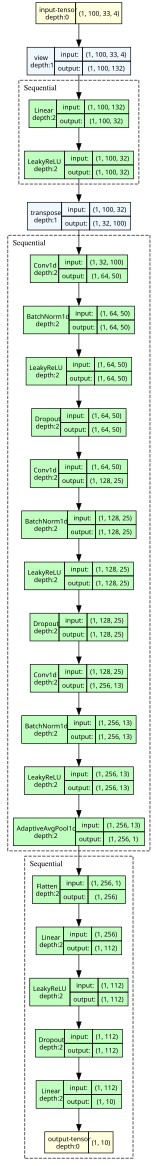

In [16]:
# show diagram of model
from torchview import draw_graph
model_for_graph = PoseModel()
# You must provide a dummy input so it can trace the shapes
model_graph = draw_graph(
    model_for_graph, 
    input_size=(1, 100, 33, 4), 
    expand_nested=True, 
    graph_dir="TB"
    )
model_graph.visual_graph

# Specify training rules

In [17]:
# train_loader, val_loader = get_dataloaders(
#         './train-data', 
#         batch_size = 10, 
#         val_split = 0.2,
#         collate_fn = collate_fn
#         )

# data, target = next(iter(train_loader))
        
# # ... send data to the right device, 
# data, target = data.to(device), target.to(device)

# # ... send data through the model
# outputs = model(data)
# outputs = torch.flatten(outputs)
# print(outputs)
# preds = torch.round(outputs).int()
# print(preds)

# # ... print mean and std of predictions if you want (helpful to see if the model is predicting the same output every time, i.e. a vanishing gradients problem).
# print(f"Output Mean: {outputs.mean().item():.4f}, Std: {outputs.std().item():.4f}")

# # ... calc loss,
# criterion = nn.MSELoss()
# loss = criterion( outputs.float() , target.float() )
# print(loss)

In [18]:
def get_model_weight_norm(model):
    total_norm = 0.0
    for p in model.parameters():
        if p.requires_grad:
            # L2 Norm: square the values, sum them, and take the square root
            param_norm = p.data.norm(2)
            total_norm += param_norm.item() ** 2
    return total_norm ** 0.5

def get_memory_footprint():
    """Returns the current System RAM and GPU VRAM usage."""
    
    # System RAM
    process = psutil.Process(os.getpid())
    ram_gb = process.memory_info().rss / ( 1024**3 )
    
    # GPU VRAM usage (only if on "cuda")
    vram_gb = 0.0
    if torch.cuda.is_available():
        # memory_allocated is the actual tensor storage
        # memory_reserved includes the cache held by PyTorch
        vram_gb = torch.cuda.memory_reserved() / (1024**3)
    elif torch.backends.mps.is_available():
        # Using driver_allocated because it reflects the actual 
        # hardware pressure on the Unified Memory pool.
        vram_gb = torch.mps.driver_allocated_memory() / (1024**3)
        
    return ram_gb, vram_gb

def train_epoch(model, train_loader, optimizer, criterion, device, print_outputs = False):
    
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    # For each batch...
    for batch_idx, (data, target) in enumerate(train_loader):
        
        # ... send data to the right device, 
        data, target = data.to(device), target.to(device)

        # ... correct target class labels (class outputs index starting at 0, the labels index at 1, so we subtract 1 from targets to match),
        target = target.long() - 1 
        
        # ... zero gradients,
        optimizer.zero_grad()

        # ... send data through the model
        outputs = model(data)
        # outputs = torch.flatten(outputs)
        # preds = torch.round(outputs).int()

        # ... print mean and std of predictions if you want (helpful to see if the model is predicting the same output every time, i.e. a vanishing gradients problem).
        if print_outputs:
            print(f"Output Mean: {outputs.mean().item():.4f}, Std: {outputs.std().item():.4f}")

        # ... calc loss,
        loss = criterion( outputs , target )

        # ... backward pass,
        loss.backward()

        # ... update optimizer,
        optimizer.step()

        # ... predict the most likely class,
        _, preds = torch.max(outputs, 1)
        
        # ...update measurements, 
        total_loss += loss.item()
        correct += (preds == target).sum().item()
        total += target.size(0)
        print(f"Loss on batch {batch_idx}: {loss.item():.4f}")

    return total_loss / len(train_loader), correct / total


def evaluate(model, test_loader, criterion, device, print_predictions = True):
    
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        
        # for each batch...
        for data, target in test_loader:
            
            # ... send to the right device,
            data, target = data.to(device), target.to(device)

            # ... fix targets to align with model outputs,
            target = target.long() - 1

            # ... send data through the model,
            outputs = model(data)
            # outputs = torch.flatten(outputs)
            # preds = torch.round(outputs)


            # ... calculate and update loss,
            total_loss += criterion( outputs , target ).item()

            # ... predict most likely class, 
            _, preds = torch.max(outputs, 1)
            
            # ... and tally accuracy.
            correct += (preds == target).sum().item()
            total += target.size(0)
            if print_predictions:
                print(f"Sample Preds: {preds[:5].cpu().numpy() + 1}")

    return total_loss / len(test_loader), correct / total



def train_model(model, epochs=5, lr=1e-4, weight_decay = 3e-4, best_val_loss = float('inf'), start_epoch = 1):
    """Train and return your model."""

    # set optimizer and loss criterion 
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay = weight_decay)
    criterion = nn.CrossEntropyLoss()
    # criterion = nn.MSELoss()

    # initialize LR scheduler (learning rate will drop to 50% the current rate after 3 epochs of no improvement)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    # dataloaders
    train_loader, val_loader = get_dataloaders(
        './training-data', 
        batch_size = 8, 
        val_split = 0.2,
        collate_fn = collate_fn
        )
    print("Got dataloaders.\n")
    print("Go time. Let the training commence.\n")

    # Initialize metrics to track
    train_losses, train_acces = [], []
    val_losses, val_acces = [], []

    # For each epoch...
    for epoch in range(start_epoch, start_epoch + epochs + 1):

        # ... grab the current learning rate, 
        current_lr = optimizer.param_groups[0]["lr"]

        # ... train and validate, 
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        # ... step the learning rate scheduler
        scheduler.step(val_loss)

        # ... and message if learning rate changed for the next epoch
        new_lr = optimizer.param_groups[0]['lr']
        if new_lr < current_lr:
            print(f"\n[LR REDUCTION] Learning rate dropped from {current_lr:.1e} to {new_lr:.1e}")

        if new_lr < 1e-8:
            print(f"\n[EARLY STOPPING] LR {new_lr:.1e} is below threshold 1e-8. Training halted.")
            break

        # ... save evaluations,
        train_losses.append(train_loss)
        train_acces.append(train_acc)
        val_losses.append(val_loss)
        val_acces.append(val_acc)

        # ... track model metrics,
        ram, vram = get_memory_footprint()
        current_norm = get_model_weight_norm(model)

        print(f"Epoch {epoch}/{start_epoch + epochs - 1} | LR: {current_lr:.1e} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f} | "
              f"RAM: {ram:.2f}GB | VRAM: {vram:.2f}GB | Weight Norm: {current_norm:.3f}")
        
        # ... and, if this is the best model so far, save it.
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_val_loss': best_val_loss,
            }
            
            torch.save(checkpoint, 'best_video_model.pth', _use_new_zipfile_serialization = False)
            print(f"--- Epoch {epoch}: New best model saved! ---")

    return model, train_losses, train_acces, val_losses, val_acces

# Train and report training outcomes

Some functions to help with reporting losses and accuracies

In [19]:
def eval_plots(loss, acc, loss_title = "Running loss, per epoch", acc_title = "Running accuracy, per epoch"):

    fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize=(8, 4))

    # Plot data on the first axis (left plot)
    ax1.plot(loss)
    ax1.set_title(loss_title)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")

    # Plot data on the second axis (right plot)
    ax2.plot(acc)
    ax2.set_title(acc_title)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")

    # Automatically adjust subplot parameters for a tight layout
    plt.tight_layout()

    # Display
    plt.show()

def report_training_results(train_losses, train_acces, val_losses, val_acces):

    eval_plots(
        train_losses, 
        train_acces, 
        "Running training loss, per epoch", 
        "Running training accuracy, per epoch" 
        )
    eval_plots(
        val_losses, 
        val_acces, 
        "Running evaluation loss, per epoch", 
        "Running evaluation accuracy, per epoch"
        )


Actual training

## FREEZING HERE
 - keep weight_decay low (3e-4)
 - adding small FC in front of convolutions
 - maxing the final temporal convolutions at 256 channels (any larger seems bad)
 - `AdaptiveAvgPool1D` instad of `AdaptiveMaxPool1D`
 - stride was at 5, max frames 200, got to 89% train acc, lets try again
    - stride of 10, max frames 200 sucked, train acc of 7%
    - stride 3, max 300, train acc 72%
    - stride 10, max 100, train acc 93.5% (best yet)
    - the point is that the stride * max_length needs to be about 1000, to account for the total length of our long videos. Any longer and we're padding with a bunch of useless information, which then gets glubbed by the `AdapativeAvgPool1d()`


In [20]:
# setting a manual seed for reproducibility
torch.manual_seed(0)
print(f"Using device: {device}\n")
model = PoseModel().to(device)
model, train_losses, train_acces, val_losses, val_acces = train_model(model, epochs = 100, lr = 1e-2, weight_decay=3e-4)

Using device: mps

Train: 264 videos, Val: 65 videos

Got dataloaders.

Go time. Let the training commence.

Loss on batch 0: 2.2892
Loss on batch 1: 2.6008
Loss on batch 2: 2.3937
Loss on batch 3: 1.9292
Loss on batch 4: 3.4737
Loss on batch 5: 2.3968
Loss on batch 6: 3.0522
Loss on batch 7: 2.6026
Loss on batch 8: 2.9609
Loss on batch 9: 2.7610
Loss on batch 10: 2.9110
Loss on batch 11: 2.7951
Loss on batch 12: 2.3304
Loss on batch 13: 2.5291
Loss on batch 14: 2.4562
Loss on batch 15: 2.3613
Loss on batch 16: 2.2930
Loss on batch 17: 2.6058
Loss on batch 18: 2.2555
Loss on batch 19: 2.9118
Loss on batch 20: 2.1399
Loss on batch 21: 2.3104
Loss on batch 22: 2.4688
Loss on batch 23: 2.3106
Loss on batch 24: 2.8043
Loss on batch 25: 2.3748
Loss on batch 26: 2.5593
Loss on batch 27: 2.8863
Loss on batch 28: 2.4237
Loss on batch 29: 2.2181
Loss on batch 30: 2.5305
Loss on batch 31: 2.1750
Loss on batch 32: 2.0700
Sample Preds: [5 5 2 2 5]
Sample Preds: [2 5 5 5 1]
Sample Preds: [5 5 5 5 2

Report outcomes for this training cycle

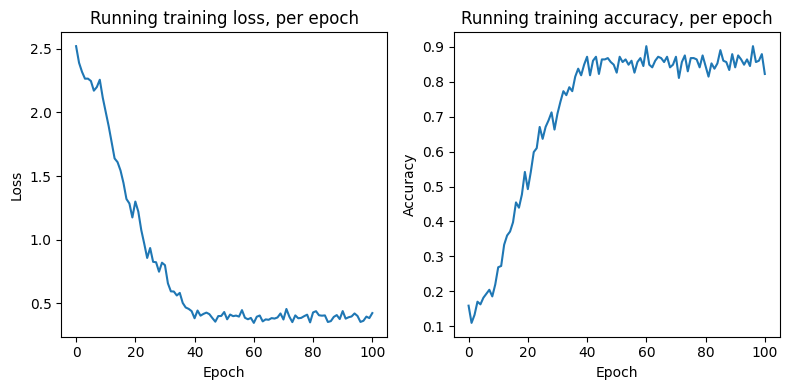

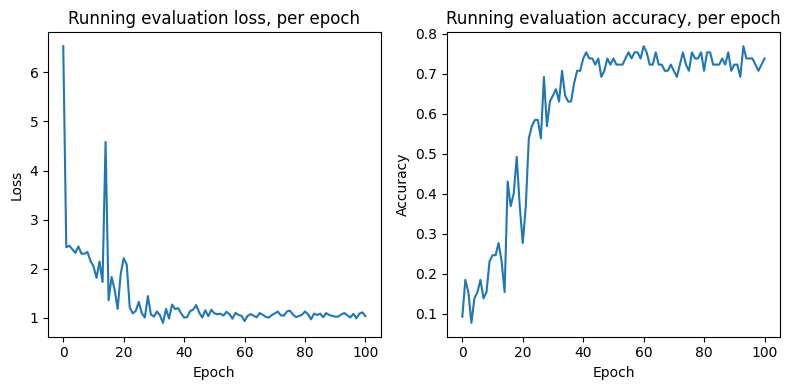

In [21]:
report_training_results(train_losses, train_acces, val_losses, val_acces)

# Full final evaluation of best model on training data

Functions to help with evaluation

In [22]:
# More comprehensive model evaluation (no transformations)
def full_evaluate(model, test_loader, dataset, device):
    model.eval()
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_times = []

    print("\n")

    with torch.no_grad():
        # for each batch, ...
        for idx, (frames, labels) in enumerate(test_loader):
            
            # ... grab the frames and labels,
            frames, labels = frames.to(device), labels.to(device)

            # ... time the forward pass,
            start_time = time.time()
            outputs = model(frames)
            if device.type == 'cuda':
                torch.cuda.synchronize()  # wait for GPU to finish
            elif device.type == "mps":
                torch.mps.synchronize()  # wait for GPU to finish
            end_time = time.time()
            inference_time = (end_time - start_time) * 1000  # ms
            all_times.append(inference_time)

            # ... make predictions
            _, preds = torch.max(outputs, 1)
            preds = preds + 1
            

            # ... evalute if we're correct or not
            for i in range(labels.size(0)):
                batch_idx = idx * test_loader.batch_size + i
                video_name = dataset.video_files[batch_idx]
                pred = preds[i].item()
                true_label = labels[i].item()
                is_correct = "✓" if pred == true_label else "✗"
                print(f"{is_correct}  pred={pred}  true={true_label}  |  {video_name}")

            # ... tally our results
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Now, generate a confusion matrix of all our incorrect predictions, ...
    unique_labels = sorted(list(set(all_labels) | set(all_preds)))
    cm = confusion_matrix(all_labels, all_preds, labels=unique_labels)
    plot_confusion_matrix(cm, unique_labels)

    # ... and tally our final accuracy
    accuracy = correct / total
    return accuracy, all_preds, all_labels, all_times

def plot_confusion_matrix(cm, labels):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted count')
    plt.ylabel('Actual count')
    plt.title('Confusion Matrix: Number of Push-ups')
    plt.show()
    
def run_inference(model, bucket_name='training-and-validation-data', dataset_loc = "./pose-data"):

    model = model.to(device)

    # Create dataloader
    val_dataset = PoseDataset(dataset_loc)
    test_loader = DataLoader(
        val_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn
    )

    print(f"\nRunning inference on {len(val_dataset)} test videos...")

    # Warmup
    if device.type == 'cuda' or device.type == "mps":
        # dummy = torch.randn(1, 3, 100, 224, 224).to(device)
        dummy = torch.randn(1, 100, 33, 4).to(device)
        with torch.no_grad():
            _ = model(dummy)
        if device.type == 'cuda':
            torch.cuda.synchronize()  # wait for GPU to finish
        elif device.type == "mps":
            torch.mps.synchronize()  # wait for GPU to finish

    total_start = time.time()
    accuracy, preds, labels, times = full_evaluate(model, test_loader, val_dataset, device)
    total_end = time.time()

    # Summary
    num_correct = sum(p == l for p, l in zip(preds, labels))
    num_wrong = len(preds) - num_correct

    print("\n" + "="*50)
    print("SUMMARY")
    print("="*50)
    print(f"Total videos:         {len(preds)}")
    print(f"Correct:              {num_correct}")
    print(f"Incorrect:                {num_wrong}")
    print(f"")
    print(f"ACCURACY:             {accuracy*100:.2f}%")
    print(f"")
    print(f"Total time:           {total_end - total_start:.2f}s")
    print(f"Avg per video:        {sum(times) / len(times):.1f}ms")
    print(f"Min latency:          {min(times):.1f}ms")
    print(f"Max latency:          {max(times):.1f}ms")
    print("="*50)
    return accuracy, preds, labels


Load the best model from training, saved as a checkpoint, and run inference

Successfully loaded model from epoch 34

Running inference on 77 test videos...


✓  pred=3  true=3  |  3_kling_20251206_Text_to_Video_Generate_a_315_2_pose.pt
✓  pred=4  true=4  |  4_kling_20251209_Text_to_Video_Generate_a_588_2_pose.pt
✓  pred=6  true=6  |  6_kling_20251209_Text_to_Video_Generate_a_218_1_pose.pt
✓  pred=3  true=3  |  3_kling_20251209_Text_to_Video_Generate_a_491_2_pose.pt
✓  pred=4  true=4  |  4_aslkjasmcalkewjlkje_pose.pt
✓  pred=3  true=3  |  3_sdlkjfaslkjfalskjdf_pose.pt
✓  pred=4  true=4  |  4_kling_20251207_Text_to_Video_Generate_a_521_1_pose.pt
✗  pred=3  true=7  |  7_sadkjfkljekj_pose.pt
✓  pred=3  true=3  |  3_kling_20251206_Text_to_Video_Generate_a_71_3_pose.pt
✓  pred=4  true=4  |  4_kling_20251209_Text_to_Video_Generate_a_218_0_pose.pt
✓  pred=2  true=2  |  2_dkdmkejkeimdh_pose.pt
✓  pred=4  true=4  |  4_kling_20251209_Text_to_Video_Generate_a_561_1_pose.pt
✓  pred=2  true=2  |  2_dkdjwkndkfw_pose.pt
✓  pred=3  true=3  |  3_ewdfkjwaeoihjlkasdjf_pose.pt
✓  

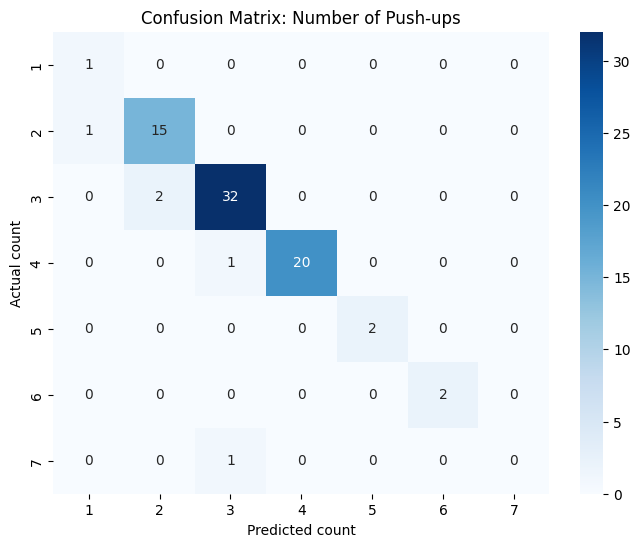


SUMMARY
Total videos:         77
Correct:              72
Incorrect:                5

ACCURACY:             93.51%

Total time:           0.46s
Avg per video:        2.1ms
Min latency:          1.5ms
Max latency:          2.8ms


In [23]:
model = PoseModel()
checkpoint = torch.load('best_video_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Successfully loaded model from epoch {checkpoint['epoch']}")
model.eval()
model.to(device)
_, _, _ = run_inference(model, dataset_loc = "./pose-data")

# Upload Model to Hugging Face

Install the dependencies:

In [24]:
!pip install huggingface_hub

You'll now need to log in to Hugging Face via the command line. To do this, you'll need to generate a token on your Hugging Face account. To generate a token, run the below command, and click on the link which appears.

In [25]:
!hf auth login

A new version of huggingface_hub (1.2.3) is available! You are using version 1.2.1.
To update, run: pip install -U huggingface_hub

User is already logged in.


The below code will only run if you have already trained a model with variable name 'model'.

The below code will take your trained model, and upload it to a *public* HuggingFace repo in your account called "mv-final-assignment".

(Note - in this example, we have set 'private=False' in the upload_to_hub method. This makes your model public).

You should double-check that your model is in fact public. To do that, you can navigate (in an incognito tab, in a browser) to https://huggingface.co/YOUR_USERNAME/YOUR_MODEL_NAME and see if that page loads. If your model is public, it will. (Simply being able to run the below code will not guarantee that your model is in fact public, because, you have now authenticated yourself with the huggingface CLI).

In [26]:
# YOUR HUGGING FACE USERNAME BELOW
hf_username = 'jjmoncus1'

In [27]:
import torch
import torch.nn as nn
from huggingface_hub import HfApi, hf_hub_download


def save_model(model, path="model.pt"):
    """Save the model weights to a file."""
    torch.save(model.state_dict(), path)
    print(f"Model saved to {path}")


def upload_to_hub(local_path="model.pt", repo_id=f"{hf_username}/mv-final-assignment"):
    """
    Upload model to Hugging Face Hub.

    Args:
        local_path: Path to your saved model file
        repo_id: Your repo in format "username/model-name"
    """
    api = HfApi()

    # Create the repo first (if it already exists, this will just skip)
    api.create_repo(
        repo_id=repo_id,
        repo_type="model",
        exist_ok=True,  # Don't error if it already exists
        private=False,  # Make it public so TAs can access
    )

    # Now upload the file
    api.upload_file(
        path_or_fileobj=local_path,
        path_in_repo="model.pt",
        repo_id=repo_id,
        repo_type="model",
    )

    print(f"Model uploaded to https://huggingface.co/{repo_id}")


# =============================================================================
# EXAMPLE USAGE
# =============================================================================

if __name__ == "__main__":

    save_model(model, "mv-final-assignment.pt")

    upload_to_hub("mv-final-assignment.pt", f"{hf_username}/mv-final-assignment")


Model saved to mv-final-assignment.pt


Processing Files (1 / 1): 100%|██████████|  671kB /  671kB,  0.00B/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  
No files have been modified since last commit. Skipping to prevent empty commit.


Model uploaded to https://huggingface.co/jjmoncus1/mv-final-assignment
